**Seasonal Agriculture Performance Analysis**

**Introduction and Objective**

This dataset contains farm level agriculture data collected across different seasons (Kharif, Rabi, Zaid), states and crops in India. It has information about weather conditions, soil, fertilizer/water usage and economic outcome (cost, revenue, profit) for each farm.

The objective of this project is to study how agricultural performance changes across the three seasons, and find out which factors (rainfall, irrigation, crop type etc.) are affecting yield and profit the most.

**Key Questions I am trying to answer:**
1. Does yield and profit differ significantly across seasons?
2. Which season has higher disease/pest risk and why?
3. Which irrigation method gives the best yield and water efficiency?
4. Which crops are more profitable, and does this depend on season?
5. Which factors are most correlated with yield?
6. Are there significant outliers in yield/profit, and
what could cause them?
7. Are seasonal patterns consistent across different states, or do they vary by region?

In [3]:
#libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [6]:
df.shape #shape of dataset

(4000, 28)

In [7]:
df.head() #first 5 rows

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.tail() #last 5 rows

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [9]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [10]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

**Checking missing value and cleaning** **data** **bold text**

In [12]:
df.isnull().sum() #check missing values

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
missing_percentage = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_percentage
})

missing_table

,Missing_Count,Missing_Percentage
Farm_ID,0,0.0
State,0,0.0
District,0,0.0
Crop,0,0.0
Season,0,0.0
Farm_Area_Hectares,0,0.0
Rainfall_mm,48,1.2
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0
Sunlight_Hours_Day,0,0.0


Only 3 columns have missing values and none of them are more than 5% of the data, so mean/group-mean filling is a reasonable approach here.

In [52]:
# handling missing values
df["Rainfall_mm"] = df.groupby("Season")["Rainfall_mm"].transform(
    lambda x: x.fillna(x.mean())
)

df["Soil_Moisture_pct"] = df.groupby("Season")["Soil_Moisture_pct"].transform(
    lambda x: x.fillna(x.mean())
)

In [15]:
df.duplicated().sum() #check duplicated records


np.int64(0)

In [16]:
num_cols = ['Farm_Area_Hectares','Rainfall_mm','Avg_Temperature_C','Humidity_pct',
            'Sunlight_Hours_Day','Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha',
            'Phosphorus_kg_ha','Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
            'Seed_Quality_Score','Yield_Tonnes_Ha','Production_Tonnes','Market_Price_INR_Tonne',
            'Total_Cost_INR','Revenue_INR','Profit_INR','Water_Used_m3',
            'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']

cat_cols = ['State','District','Crop','Season','Irrigation_Method']

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 22
Categorical columns: 5


**Statistical Analysis**

In [17]:
stats_df = pd.DataFrame({
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std': df[num_cols].std(),
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'skew': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt()
})
stats_df

,mean,median,std,min,max,skew,kurtosis
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00,-0.035090,-1.221209
Rainfall_mm,600.714313,581.0000,288.427366,80.000,1395.20,0.141755,-0.860642
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70,0.002294,-0.511868
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00,-0.023558,-0.326950
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00,0.072844,-0.059978
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40,0.051516,-0.223634
Soil_Moisture_pct,26.504525,26.4000,6.696998,8.000,47.00,-0.031619,-0.369382
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00,0.020245,-0.178171
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00,0.076010,-0.074572
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00,-0.050162,-0.061093


**Descriptive Statistics**

In [18]:
df.describe() #statistics of data

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.714313,26.81890,63.210500,7.323050,6.701010,26.504525,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.427366,3.81818,11.960834,1.121186,0.641461,6.696998,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,836.125000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [19]:
print("Skewness of numeric columns:")
print(df[num_cols].skew().sort_values(ascending=False))

print("\nKurtosis of numeric columns:")
print(df[num_cols].kurt().sort_values(ascending=False))

Skewness of numeric columns:
Production_Tonnes                5.129464
Water_Efficiency_t_per_1000m3    4.279447
Yield_Tonnes_Ha                  4.039389
Profit_INR                       2.419439
Revenue_INR                      2.290794
Water_Used_m3                    1.911904
Market_Price_INR_Tonne           0.614782
Total_Cost_INR                   0.167072
Rainfall_mm                      0.141755
Phosphorus_kg_ha                 0.076010
Sunlight_Hours_Day               0.072844
Fertilizer_kg_ha                 0.067576
Soil_pH                          0.051516
Disease_Pest_Risk_pct            0.047746
Nitrogen_kg_ha                   0.020245
Pesticide_Litre_ha               0.018263
Avg_Temperature_C                0.002294
Humidity_pct                    -0.023558
Seed_Quality_Score              -0.026561
Soil_Moisture_pct               -0.031619
Farm_Area_Hectares              -0.035090
Potassium_kg_ha                 -0.050162
dtype: float64

Kurtosis of numeric columns:
Pr

In [20]:
df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]].mean()

,0
Rainfall_mm,600.714313
Avg_Temperature_C,26.818900
Humidity_pct,63.210500
Yield_Tonnes_Ha,5.270595
Profit_INR,111556.465000
Water_Used_m3,6045.570250
Disease_Pest_Risk_pct,46.365875


In [21]:
df[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]].median()

,0
Rainfall_mm,581.00
Avg_Temperature_C,26.90
Yield_Tonnes_Ha,1.74
Profit_INR,3673.00


In [22]:
print('SUMMARY')
print("\nAverage Values:")
print("Average Rainfall:", round(df["Rainfall_mm"].mean(), 2), "mm")
print("Average Temperature:", round(df["Avg_Temperature_C"].mean(), 2), "°C")
print("Average Yield:", round(df["Yield_Tonnes_Ha"].mean(), 2), "tonnes/ha")
print("Average Profit: ₹", round(df["Profit_INR"].mean(), 2))
print("Average Water Used:", round(df["Water_Used_m3"].mean(), 2), "m³")
print("Average Disease/Pest Risk:",
      round(df["Disease_Pest_Risk_pct"].mean(), 2), "%")

SUMMARY

Average Values:
Average Rainfall: 600.71 mm
Average Temperature: 26.82 °C
Average Yield: 5.27 tonnes/ha
Average Profit: ₹ 111556.46
Average Water Used: 6045.57 m³
Average Disease/Pest Risk: 46.37 %


Production_Tonnes, Water_Efficiency and Yield_Tonnes_Ha have the highest skew values (all above 4), which means their distribution is heavily pulled to the right by some very large values. Profit_INR and Revenue_INR are also skewed. This matches with what I find later in outlier analysis.

**Season-wise Analysis**

In [23]:
df["Season"].unique() #check unique values

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

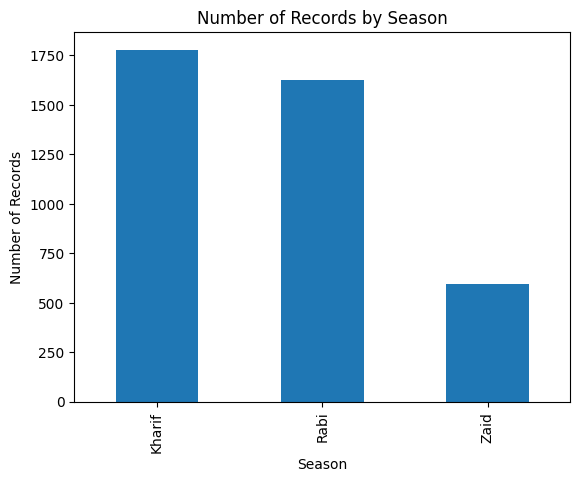

In [24]:
df["Season"].value_counts().plot(kind="bar")

plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

In [25]:
df["Crop"].unique()

array(['Wheat', 'Maize', 'Pulses', 'Rice', 'Cotton', 'Chilli',
       'Groundnut', 'Sugarcane'], dtype=object)

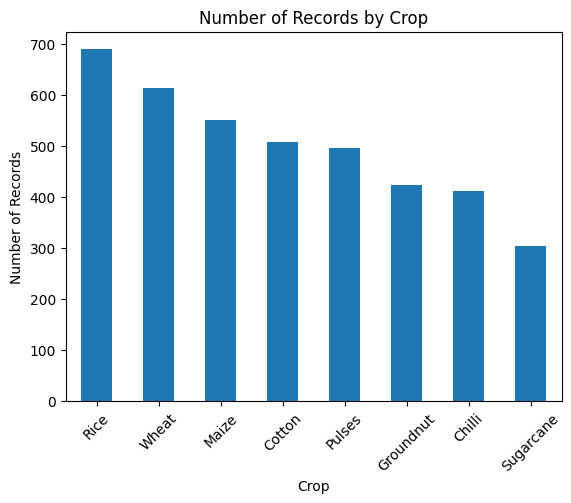

In [26]:
df["Crop"].value_counts().plot(kind="bar")

plt.title("Number of Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

Kharif has the most records among the three seasons, and Rice/Wheat appear to be among the more frequently grown crops in this dataset.

In [27]:
df["State"].unique()


array(['Andhra Pradesh', 'Maharashtra', 'Telangana', 'Karnataka',
       'Gujarat', 'Tamil Nadu', 'Punjab', 'Madhya Pradesh'], dtype=object)

In [28]:
df["Irrigation_Method"].unique()


array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

In [29]:
yield_by_season = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(yield_by_season) # yield

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


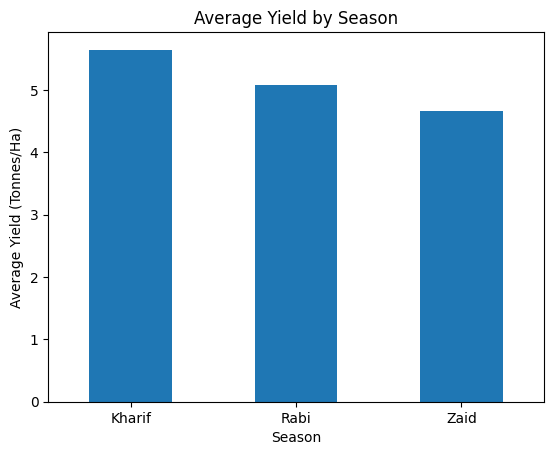

In [30]:
yield_by_season.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.show()

In [31]:
#profit
profit_by_season = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

print(profit_by_season)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


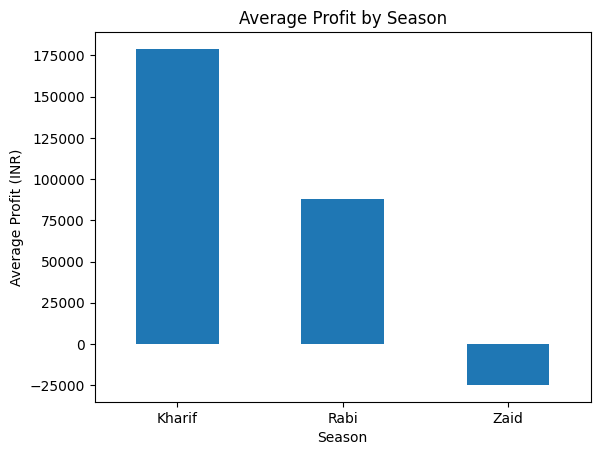

In [32]:
profit_by_season.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.show()

In [33]:
# Simple Summary

best_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax()
best_profit = df.groupby("Season")["Profit_INR"].mean().idxmax()

print("Summary:")
print("The season with the highest average yield is", best_yield)
print("The season with the highest average profit is", best_profit)

Summary:
The season with the highest average yield is Kharif
The season with the highest average profit is Kharif


Kharif season has the highest average yield (5.64 t/ha) and highest average profit (₹1,78,914), followed by Rabi (5.08 t/ha, ₹87,689). Zaid season actually shows a **negative average profit** (-₹24,804), meaning many farms in Zaid are running at a loss. This is an important finding — Zaid season farming seems the least profitable of the three, even though yield isn't drastically lower, which suggests cost of cultivation is too high relative to output in that season.

**Univariate Analysis**
(Numerical Column)

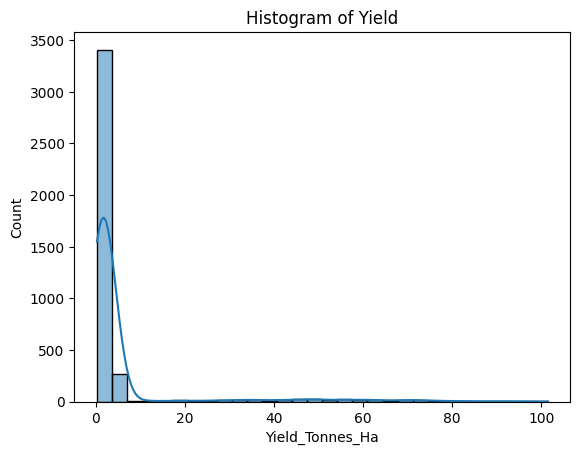

In [34]:
sns.histplot(df['Yield_Tonnes_Ha'], kde=True, bins=30)
plt.title('Histogram of Yield')
plt.show()

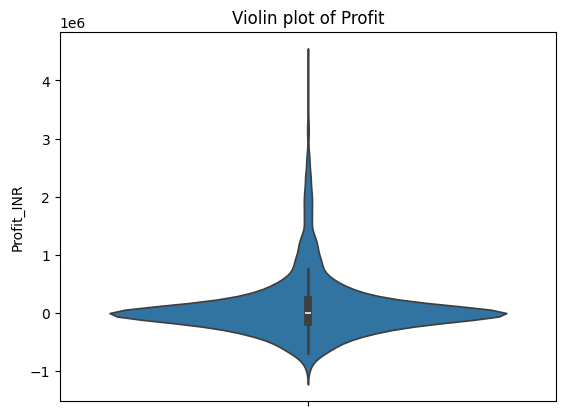

In [35]:
sns.violinplot(y=df['Profit_INR'])
plt.title('Violin plot of Profit')
plt.show()

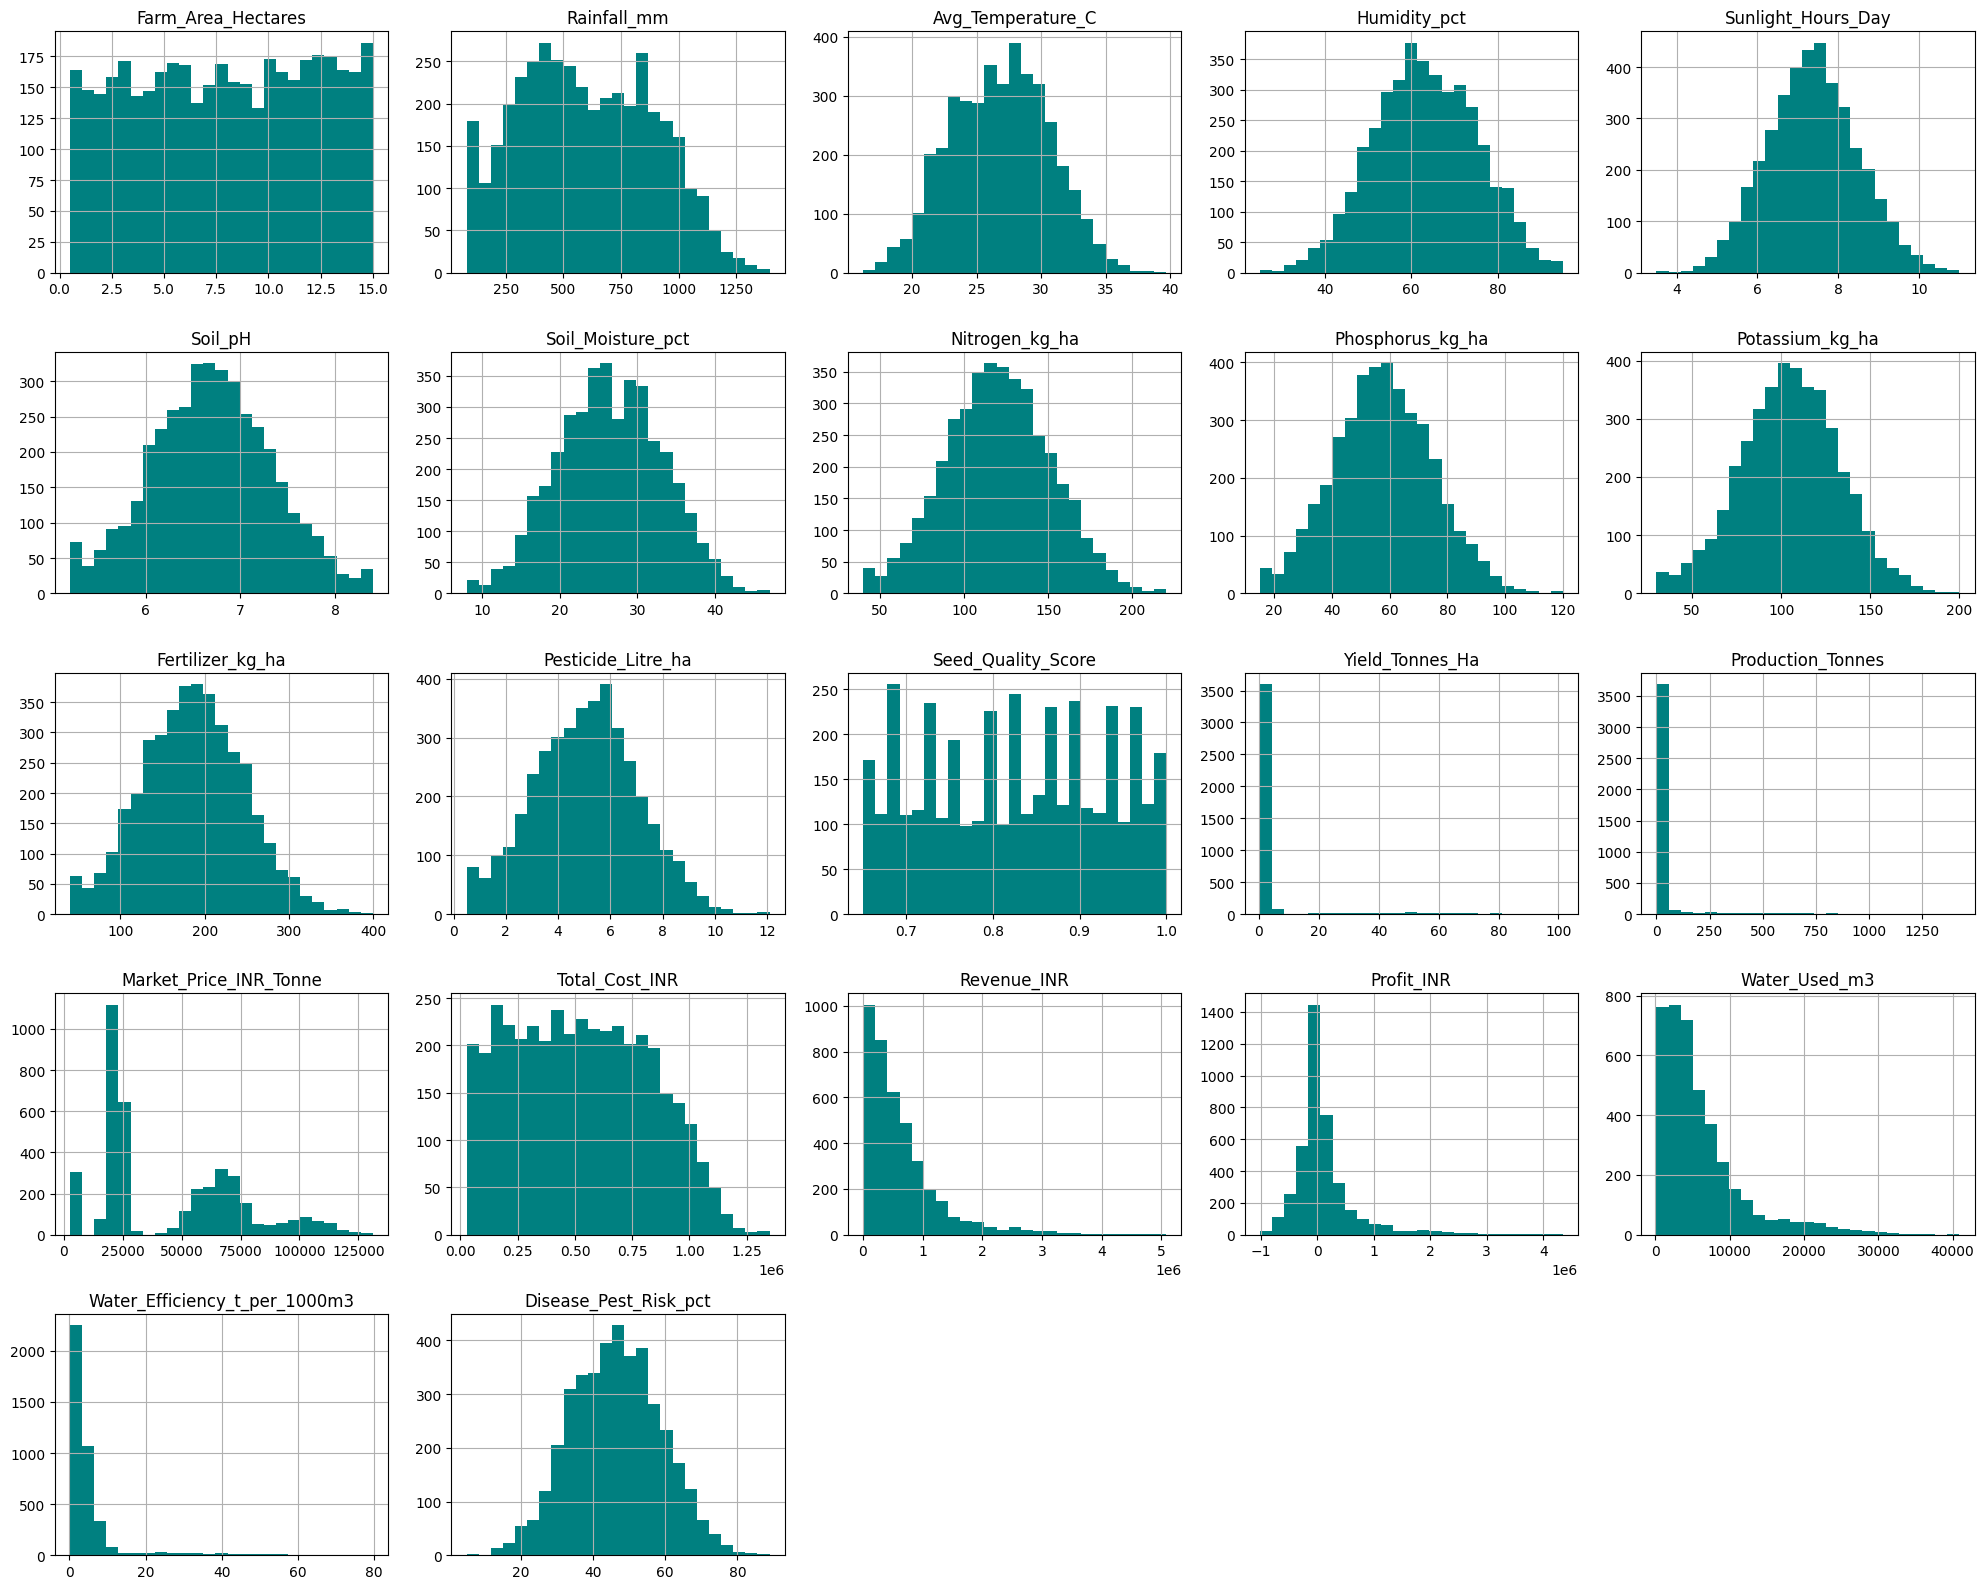

In [36]:
df[num_cols].hist(figsize=(20,16), bins=25, color='teal')
plt.tight_layout()
plt.show()

Numeric columns - Boxplots (spread and outliers)

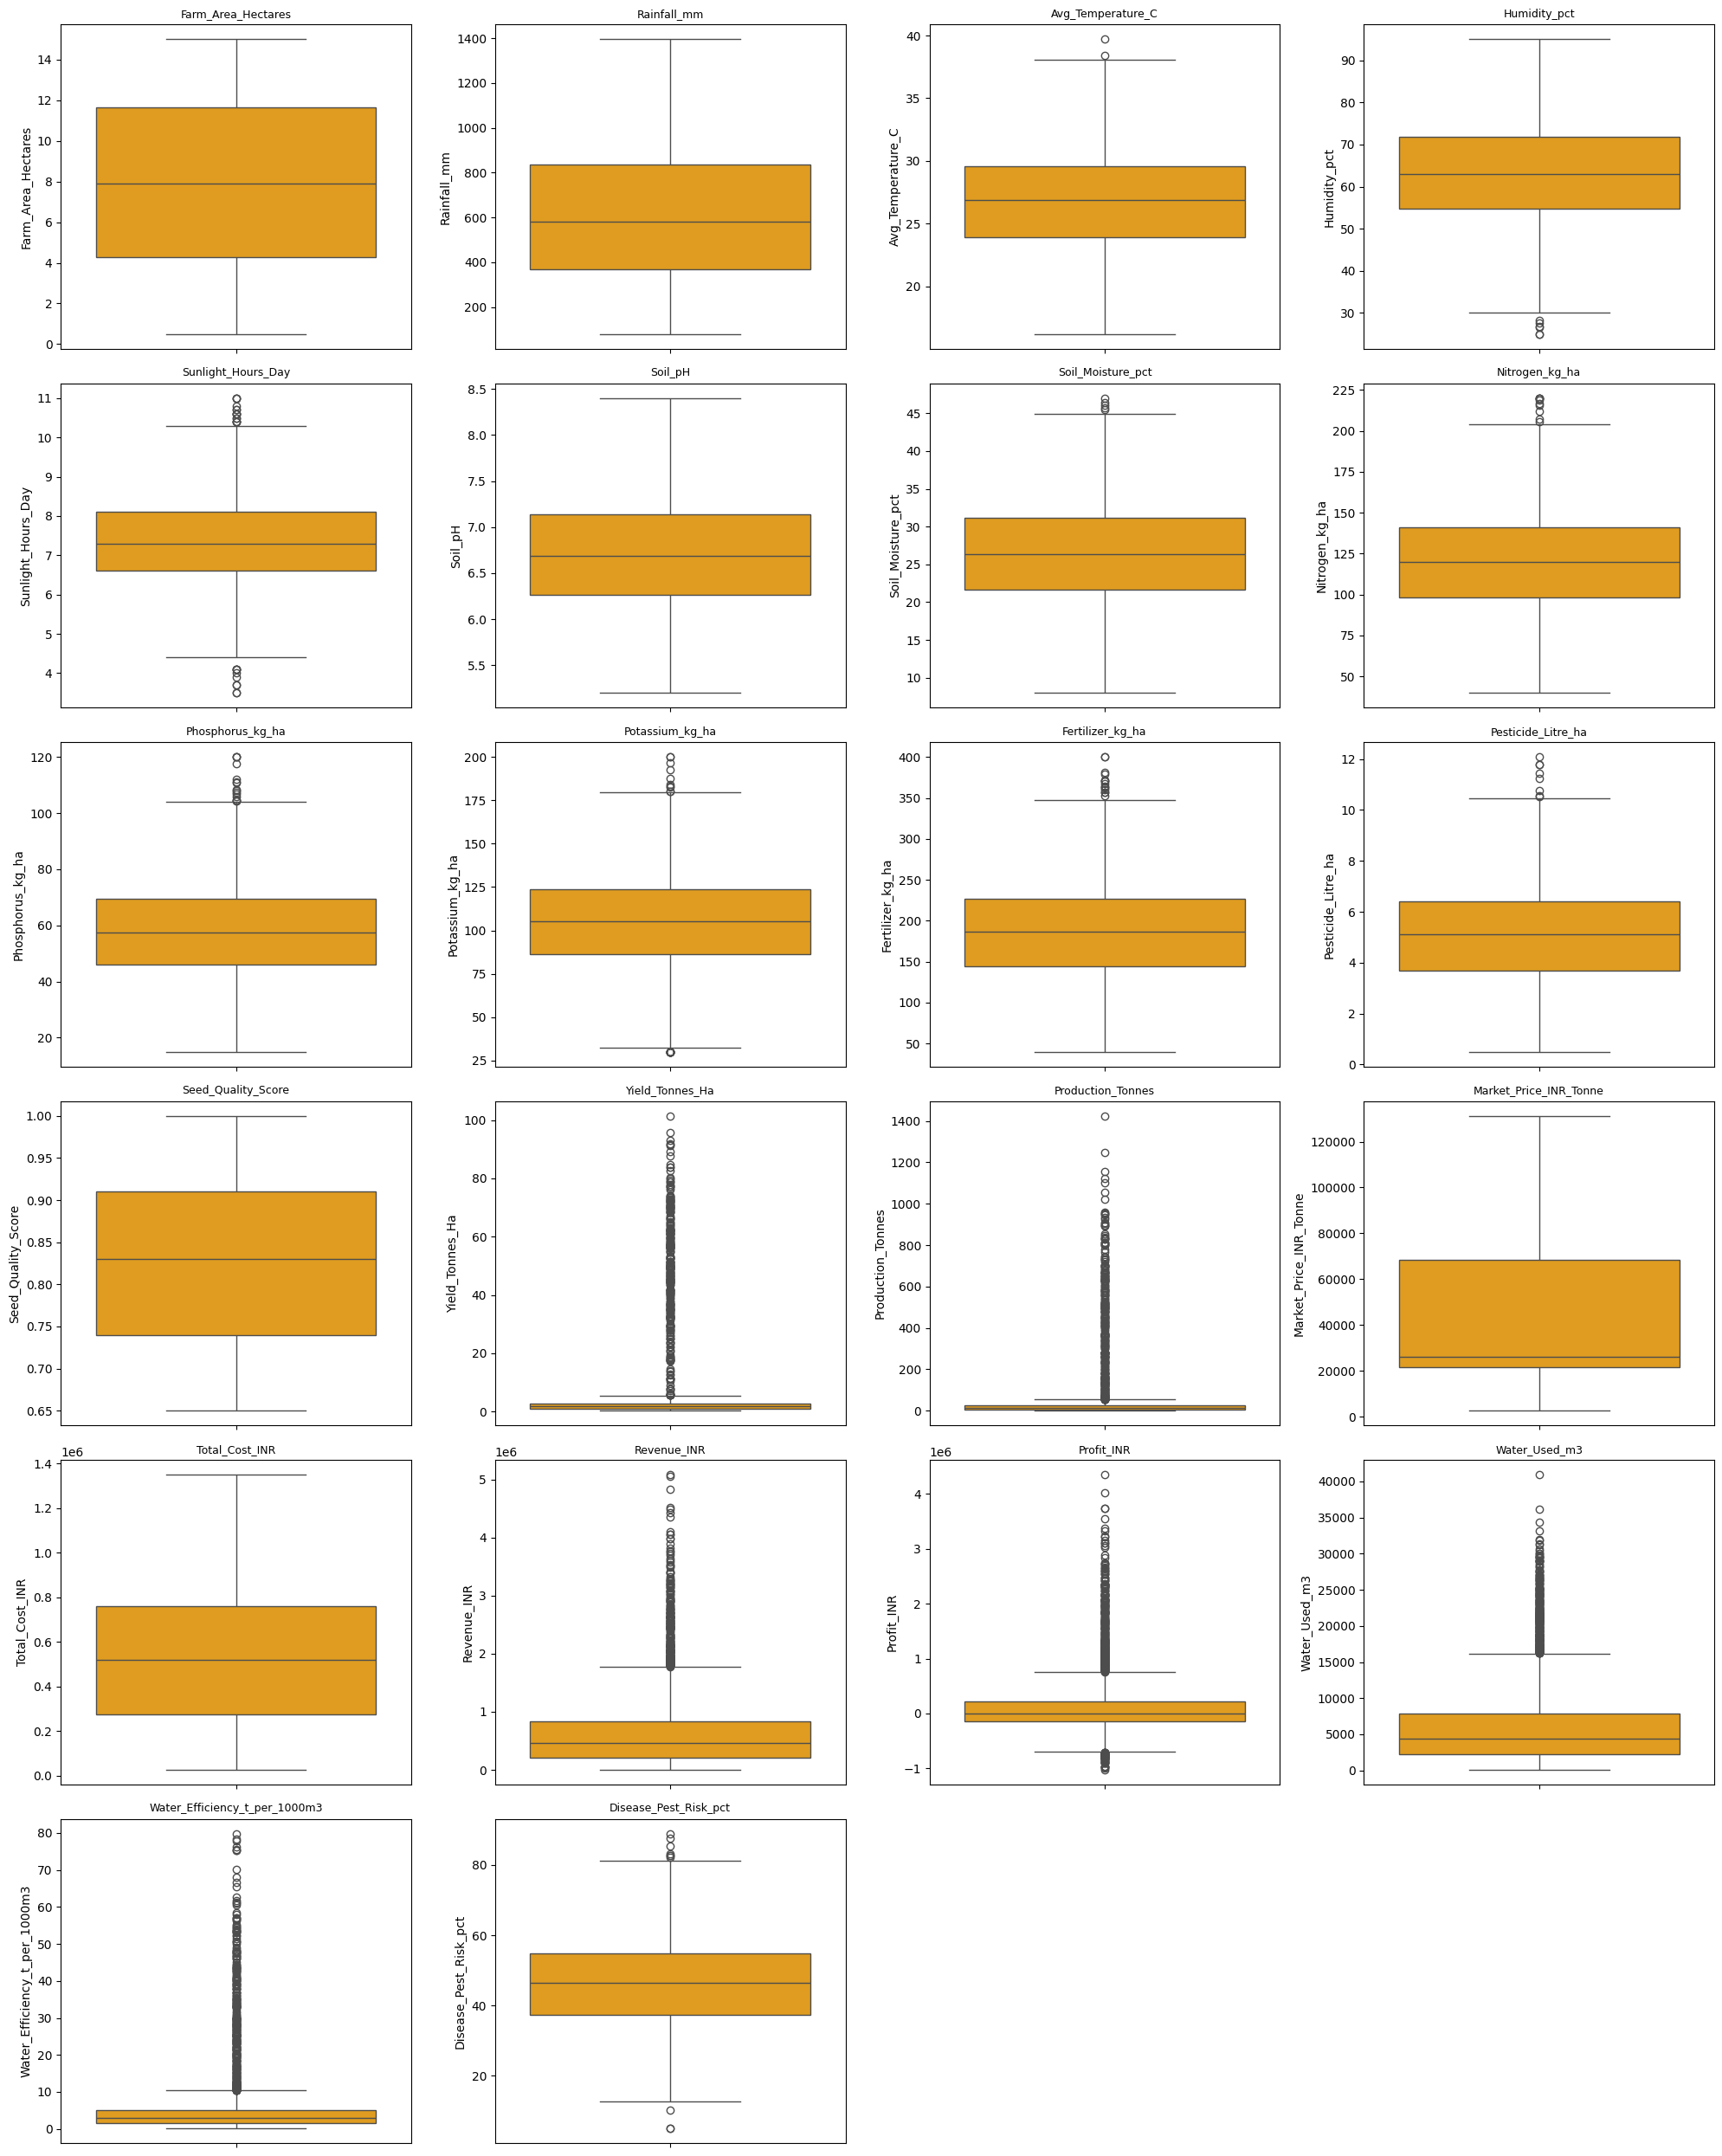

In [37]:
plt.figure(figsize=(20,25))
for i, col in enumerate(num_cols):
    plt.subplot(6,4,i+1)
    sns.boxplot(y=df[col], color='orange')
    plt.title(col, fontsize=9)
plt.tight_layout()
plt.show()

Categorical columns - pie Charts

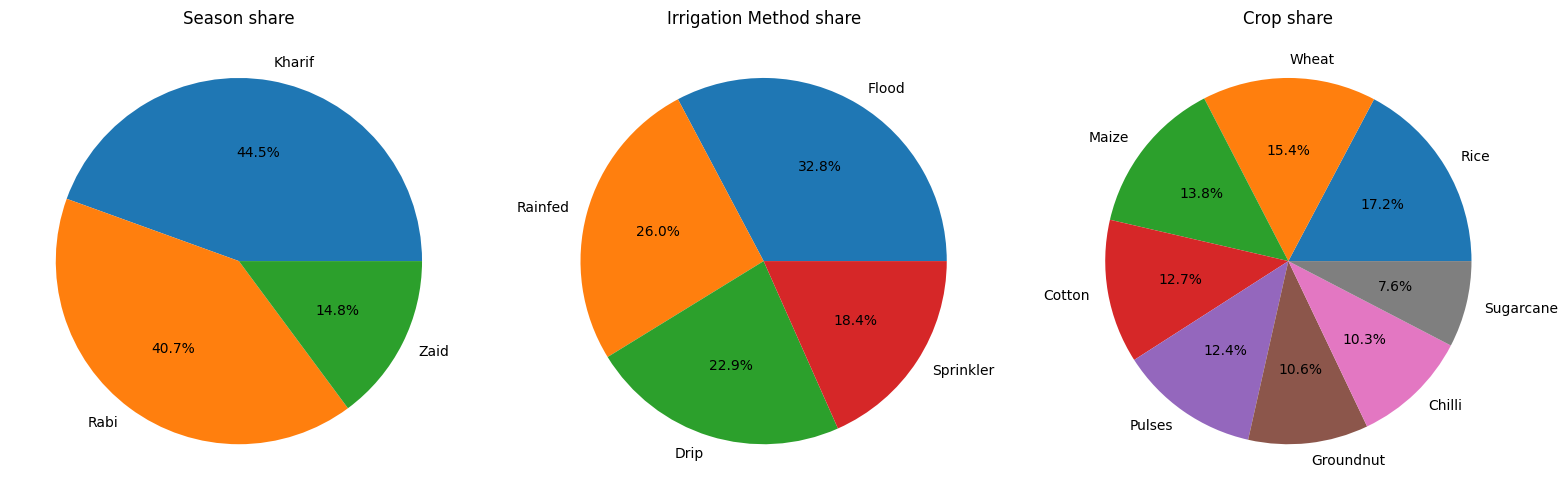

In [38]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
df['Season'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Season share')
axes[0].set_ylabel('')

df['Irrigation_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Irrigation Method share')
axes[1].set_ylabel('')

df['Crop'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[2])
axes[2].set_title('Crop share')
axes[2].set_ylabel('')
plt.tight_layout()
plt.show()

From the histograms, most columns like Temperature, Humidity, Soil_pH look roughly normal (bell-shaped). But Yield_Tonnes_Ha, Production_Tonnes, Profit_INR and Water_Efficiency show a long right tail — a small number of farms have very high values compared to the rest, confirmed by their high skewness value above.

From the boxplots, the same columns (Yield, Profit, Production, Water_Efficiency) show many points above the upper whisker, meaning they have several outliers, which I check in more detail in the outlier analysis section.

The pie charts show Kharif season has the largest share of records, and Drip irrigation is the most used method in this dataset.

**Bivariate Analysis**(numerical)

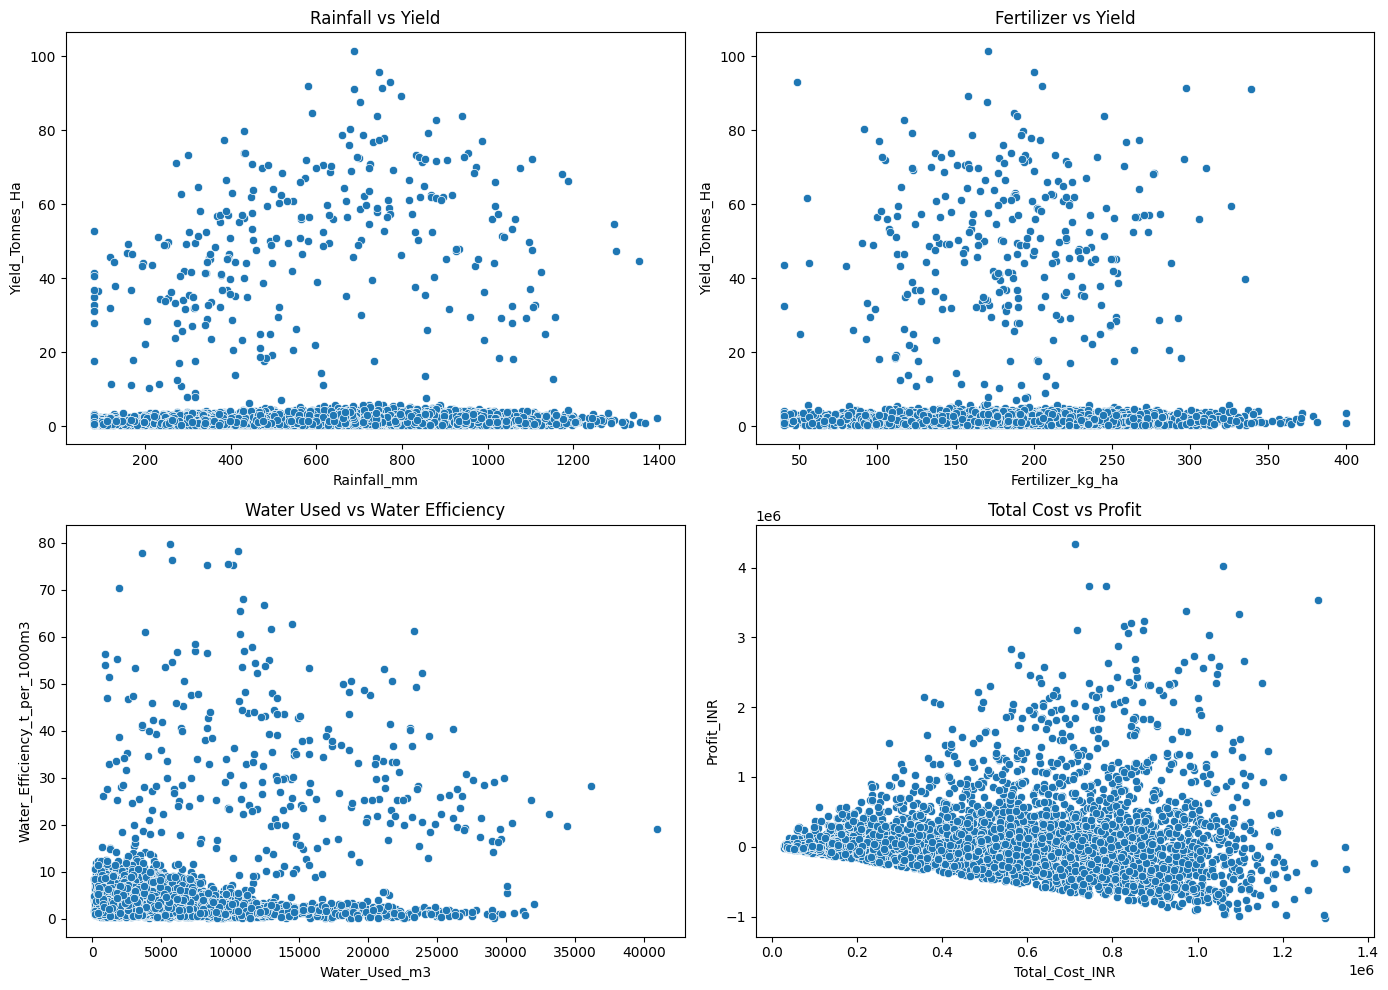

In [39]:
fig, axes = plt.subplots(2,2, figsize=(14,10)) #scatterplots
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df, ax=axes[0,0])
axes[0,0].set_title('Rainfall vs Yield')

sns.scatterplot(x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', data=df, ax=axes[0,1])
axes[0,1].set_title('Fertilizer vs Yield')

sns.scatterplot(x='Water_Used_m3', y='Water_Efficiency_t_per_1000m3', data=df, ax=axes[1,0])
axes[1,0].set_title('Water Used vs Water Efficiency')

sns.scatterplot(x='Total_Cost_INR', y='Profit_INR', data=df, ax=axes[1,1])
axes[1,1].set_title('Total Cost vs Profit')
plt.tight_layout()
plt.show()

The scatter plot of Rainfall vs Yield does not show a very clear straight-line pattern, meaning rainfall alone doesn't decide yield — other factors are involved too. This is confirmed later in the correlation results.

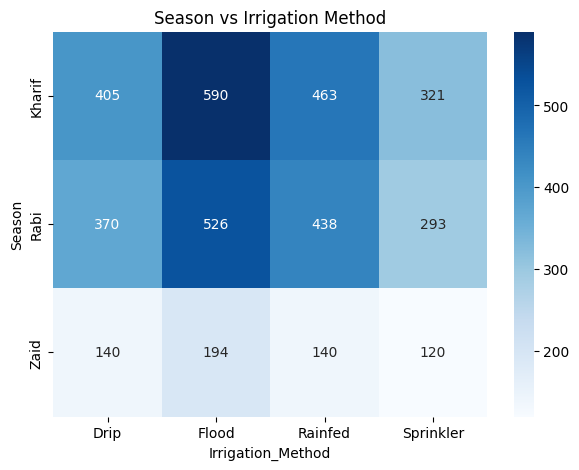

In [40]:
plt.figure(figsize=(7,5)) #categorical
sns.heatmap(pd.crosstab(df['Season'], df['Irrigation_Method']), annot=True, fmt='d', cmap='Blues')
plt.title('Season vs Irrigation Method')
plt.show()

The heatmap shows irrigation method usage is fairly spread across all three seasons, with no single method being used exclusively in one season.

In [42]:
df[num_cols].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.915438
Production_Tonnes,0.885171
Profit_INR,0.489822
Revenue_INR,0.433648
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Total_Cost_INR,0.030814
Farm_Area_Hectares,0.030188


Yield_Tonnes_Ha is most strongly correlated with Water_Efficiency (0.91) and Production_Tonnes (0.88), which makes sense since more efficient water use and more production naturally mean higher yield. It also has a moderate positive correlation with Profit (0.49) and Revenue (0.43).

Interestingly, Market_Price_INR_Tonne has a negative correlation (-0.38) with yield — meaning crops with lower yield tend to have a higher market price per tonne (like cash crops), while high-yield crops are priced lower per tonne. Most other factors like Rainfall, Fertilizer, Soil pH show almost no correlation with yield individually — showing that yield is affected by a combination of factors, not just one.

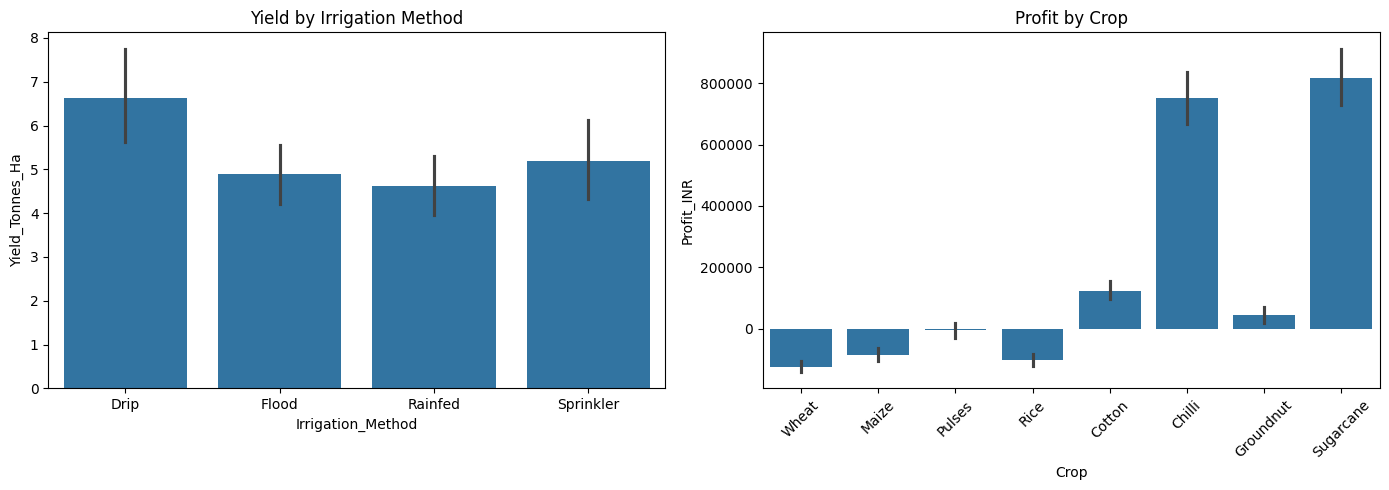

In [41]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x='Irrigation_Method', y='Yield_Tonnes_Ha', data=df, ax=axes[0])
axes[0].set_title('Yield by Irrigation Method')

sns.barplot(x='Crop', y='Profit_INR', data=df, ax=axes[1])
axes[1].set_title('Profit by Crop')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Drip irrigation gives the highest average yield (6.6 t/ha) compared to Sprinkler (5.2), Flood (4.9) and Rainfed (4.6). This makes sense as drip irrigation delivers water directly and efficiently to the roots.

For crops, Sugarcane and Chilli show the highest average profit, while Rice, Wheat and Maize actually show a **negative average profit** in this dataset. This could be because these are staple/bulk crops with lower market price per tonne compared to cash crops like Sugarcane and Chilli.

**Multivariate Analysis**

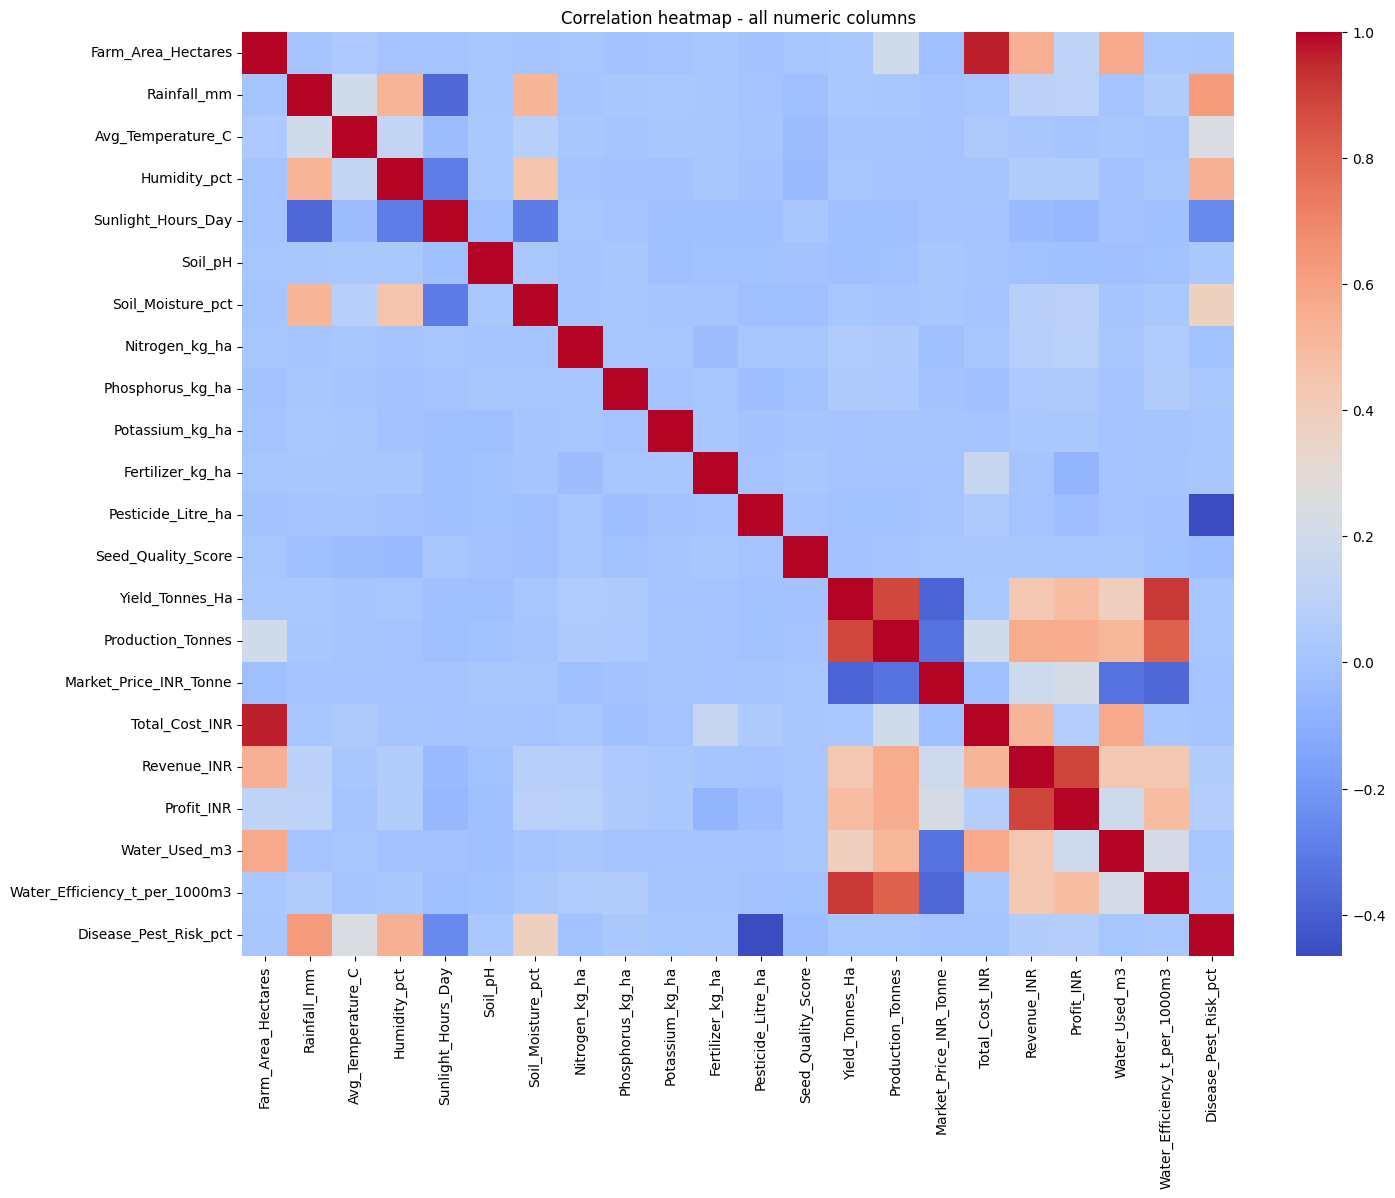

In [43]:
plt.figure(figsize=(16,12)) #correlation heatmap for all numeric columns
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation heatmap - all numeric columns')
plt.show()

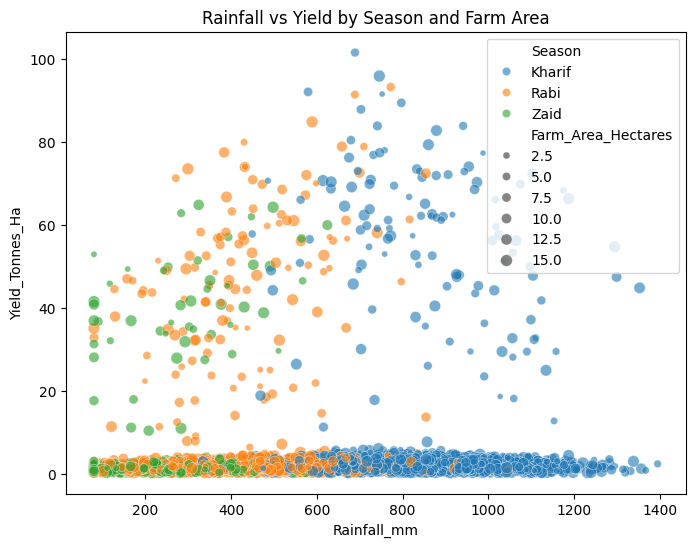

In [44]:
plt.figure(figsize=(8,6)) #scatterplot
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', size='Farm_Area_Hectares', data=df, alpha=0.6)
plt.title('Rainfall vs Yield by Season and Farm Area')
plt.show()

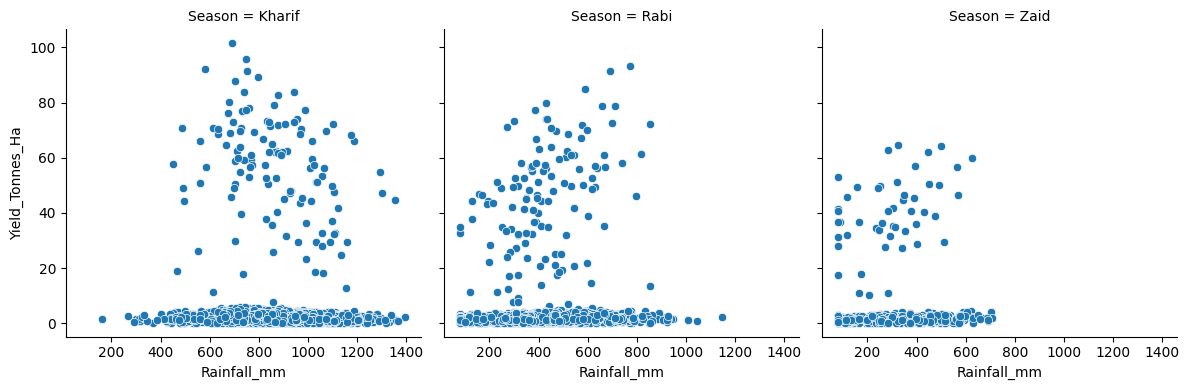

In [45]:
g = sns.FacetGrid(df, col='Season', height=4)
g.map(sns.scatterplot, 'Rainfall_mm', 'Yield_Tonnes_Ha')
plt.show()

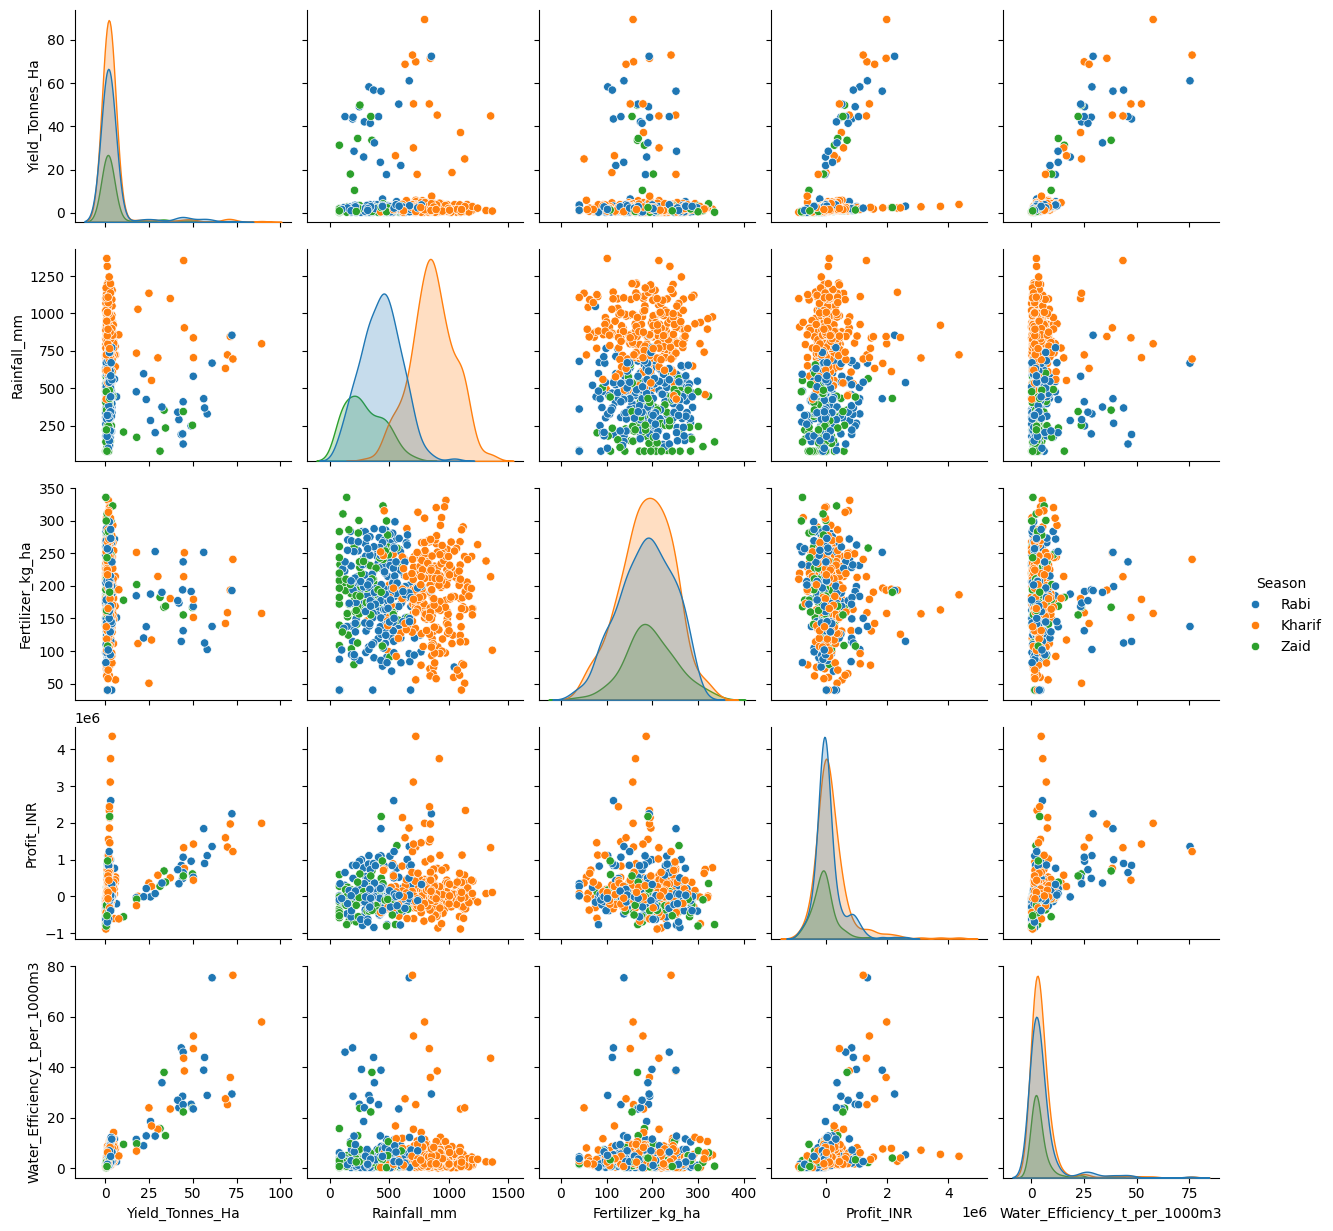

In [46]:
sample_df = df[['Yield_Tonnes_Ha','Rainfall_mm','Fertilizer_kg_ha','Profit_INR','Water_Efficiency_t_per_1000m3','Season']].sample(600, random_state=1)
sns.pairplot(sample_df, hue='Season')
plt.show() #pairplot

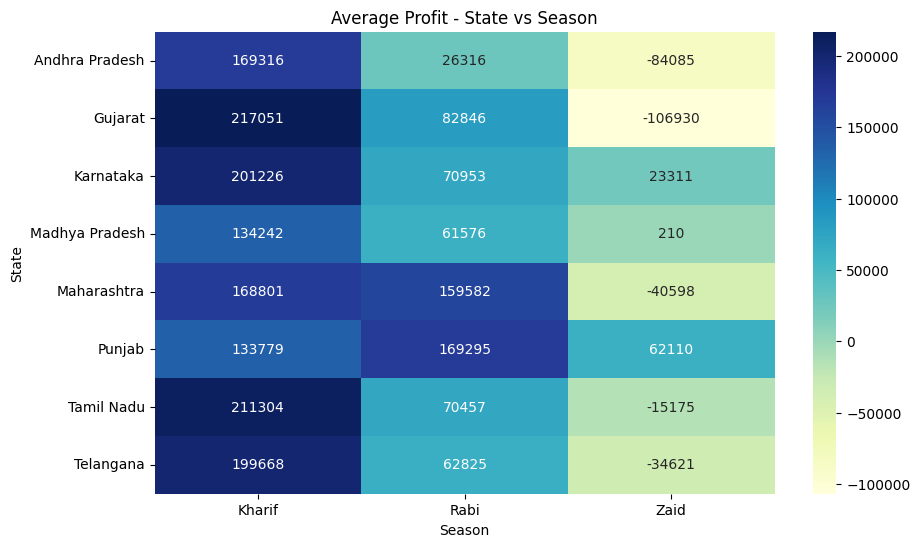

In [47]:
state_season_profit = df.groupby(['State','Season'])['Profit_INR'].mean().unstack()
plt.figure(figsize=(10,6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Profit - State vs Season')
plt.show()

In [48]:
df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Irrigation_Method,
Rainfed,7.563784
Drip,6.267129
Sprinkler,4.669805
Flood,3.438853


Rainfed method actually shows the highest water efficiency (7.56), followed by Drip (6.27). This seems surprising at first, but it's because Rainfed farming uses little to no extra irrigation water, so any yield it gets is "efficient" relative to the very small water input — it doesn't necessarily mean rainfed is the better method overall, just that the ratio looks high due to low water use in the denominator.

**Outliers Analysis**

In [49]:
outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_counts[col] = count

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Column','Outlier_Count'])
outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Column,Outlier_Count
18,Profit_INR,404
14,Production_Tonnes,333
20,Water_Efficiency_t_per_1000m3,322
13,Yield_Tonnes_Ha,302
19,Water_Used_m3,276
17,Revenue_INR,240
9,Potassium_kg_ha,32
4,Sunlight_Hours_Day,26
8,Phosphorus_kg_ha,16
10,Fertilizer_kg_ha,15


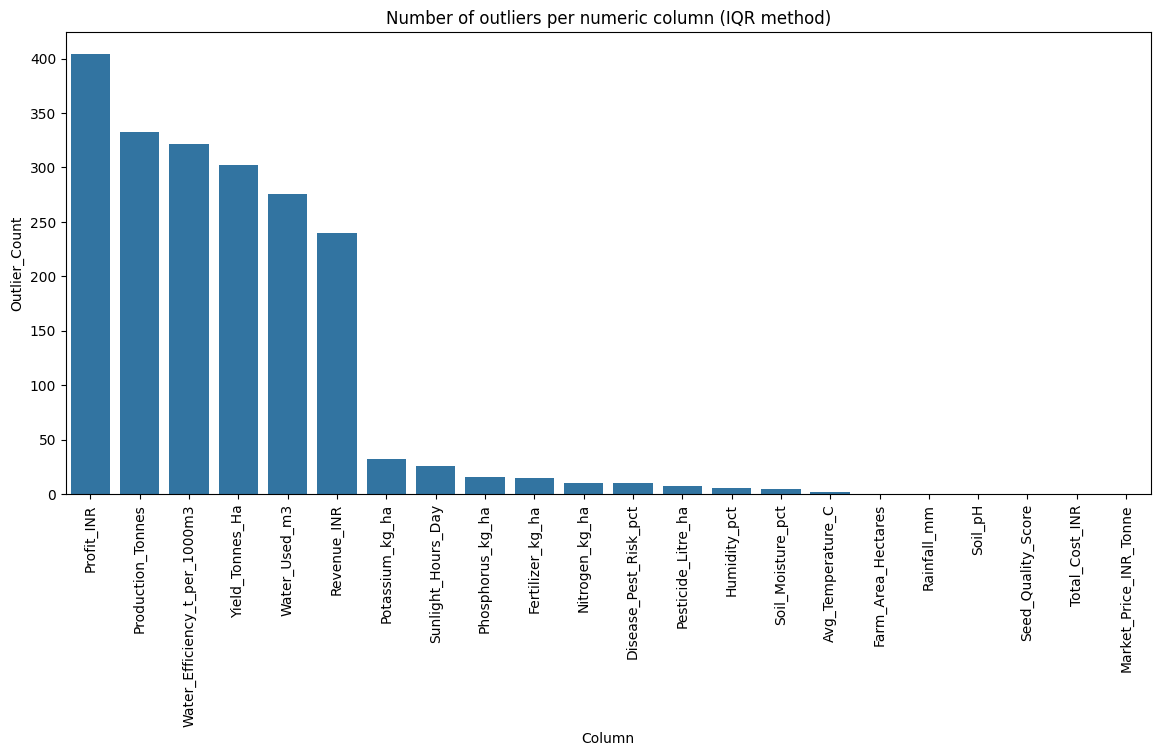

In [50]:
plt.figure(figsize=(14,6))
sns.barplot(x='Column', y='Outlier_Count', data=outlier_df.sort_values(by='Outlier_Count', ascending=False))
plt.xticks(rotation=90)
plt.title('Number of outliers per numeric column (IQR method)')
plt.show()

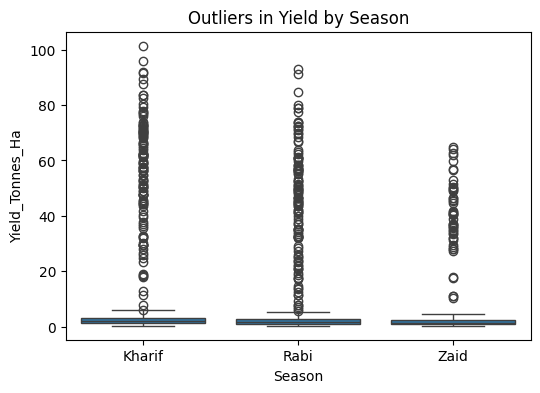

In [51]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Outliers in Yield by Season')
plt.show()

The outlier bar chart confirms that Production_Tonnes, Yield_Tonnes_Ha, Profit_INR and Water_Efficiency have the most outliers, matching the skewness values I found earlier. Looking at the season-wise boxplot, Kharif season shows a few very high yield outliers, these could be genuinely high-performing farms (maybe better soil/irrigation) or possible data entry errors — this would need to be checked with someone who knows the source of the data.

**Conclusion and Recommendations**

Findings:
1. Kharif season has the highest yield and profit; Zaid season actually shows a negative average profit, making it the least financially viable season in this dataset.
2. Disease/pest risk is highest in Kharif (54.5%) compared to Rabi (40.5%) and Zaid (38.2%), likely due to higher humidity and rainfall.
3. Drip irrigation gives the best yield among all methods, while Rainfed shows the highest water-efficiency ratio (though this is mainly because it uses very little water, not because it's the most productive method).
4. Cash crops like Sugarcane and Chilli are far more profitable than staple crops like Rice, Wheat and Maize, which actually show losses on average in this dataset.
5. Yield is mainly driven by Water_Efficiency and Production, and has little direct correlation with individual factors like rainfall or fertilizer alone.
6. Yield, Profit, Production and Water_Efficiency columns have a good number of outliers/high-performing farms that pull the average up.

Recommendations:
- Farmers growing low-margin crops (Rice, Wheat, Maize) in Zaid season should be supported with subsidies or better market pricing, since this combination shows losses in the data.
- Wider adoption of Drip irrigation should be encouraged for its higher yield.
- Extra pest management support should be planned specifically for Kharif season.
- The high-outlier farms should be studied individually to identify best practices that could be shared with others.

Limitations:
- Missing values in Rainfall, Soil_Moisture and Yield were filled using mean/group-mean, which may slightly affect precision.
- Outliers were analyzed but not removed from the main analysis, since they may represent genuine top-performing farms.
- The dataset appears to be a single-period snapshot, so trends across multiple years could not be studied.